In [2]:
from pathlib import Path
import pandas as pd

file_path = Path(
    r"C:\Users\hp\Downloads\archive (2)"
    r"\healthcare_analytics_patient_flow_data.csv"
)

patient_flow = pd.read_csv(file_path)

print("Total records:", len(patient_flow))
print("Columns:", patient_flow.columns.tolist())

display(
    patient_flow[
        [
            "Department Referral",
            "Patient Admission Date",
            "Patient Admission Time",
            "Patient Satisfaction Score",
            "Patient Waittime",
        ]
    ].head()
)

print("\nMissing values:")
print(
    patient_flow[
        [
            "Department Referral",
            "Patient Admission Date",
            "Patient Admission Time",
            "Patient Satisfaction Score",
            "Patient Waittime",
        ]
    ].isna().sum()
)

print("\nWait-time summary:")
print(patient_flow["Patient Waittime"].describe())

Total records: 9216
Columns: ['Patient Id', 'Patient Admission Date', 'Patient Admission Time', 'Merged', 'Patient Gender', 'Patient Age', 'Patient Race', 'Department Referral', 'Patient Admission Flag', 'Patient Satisfaction Score', 'Patient Waittime']


,Department Referral,Patient Admission Date,Patient Admission Time,Patient Satisfaction Score,Patient Waittime
0,NaN,9/9/2024,9:25:00 AM,5.0,32
1,Orthopedics,9/9/2024,4:42:00 PM,NaN,22
2,General Practice,9/9/2024,12:14:00 AM,NaN,16
3,General Practice,9/9/2024,8:33:00 PM,NaN,38
4,NaN,9/9/2024,7:25:00 PM,NaN,36



Missing values:
Department Referral           5400
Patient Admission Date           0
Patient Admission Time           0
Patient Satisfaction Score    6699
Patient Waittime                 0
dtype: int64

Wait-time summary:
count    9216.000000
mean       35.259874
std        14.735323
min        10.000000
25%        23.000000
50%        35.000000
75%        48.000000
max        60.000000
Name: Patient Waittime, dtype: float64


In [4]:
patient_flow["department"] = (
    patient_flow["Department Referral"]
    .fillna("Unknown")
)

wait_by_department = (
    patient_flow.groupby(
        "department",
        observed=True,
    )["Patient Waittime"]
    .agg(["count", "mean", "median"])
    .sort_values("mean", ascending=False)
    .round(2)
)

display(wait_by_department)

,count,mean,median
department,,,
Neurology,193,36.80,38.0
Physiotherapy,276,36.57,38.5
Gastroenterology,178,35.83,36.0
Cardiology,248,35.35,35.0
Unknown,5400,35.29,35.0
Orthopedics,995,34.98,34.0
General Practice,1840,34.91,35.0
Renal,86,34.70,35.0


,count,mean,median
admission_hour,,,
0,406,34.25,34.0
1,372,34.06,35.0
2,376,35.36,34.5
3,385,37.22,38.0
4,384,34.93,35.0
5,393,36.39,38.0
6,375,35.13,34.0
7,415,35.26,36.0
8,386,35.32,35.5


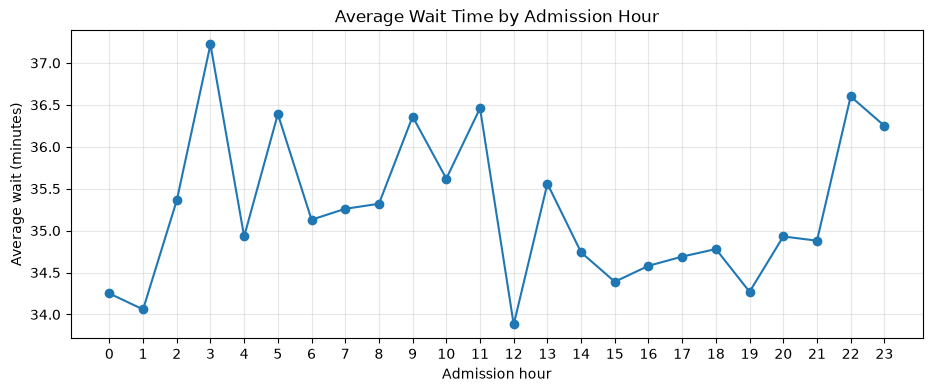

In [6]:
patient_flow["admission_hour"] = pd.to_datetime(
    patient_flow["Patient Admission Time"],
    format="%I:%M:%S %p",
).dt.hour

wait_by_hour = (
    patient_flow.groupby(
        "admission_hour"
    )["Patient Waittime"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(wait_by_hour)

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 4))

plt.plot(
    wait_by_hour.index,
    wait_by_hour["mean"],
    marker="o",
)

plt.title("Average Wait Time by Admission Hour")
plt.xlabel("Admission hour")
plt.ylabel("Average wait (minutes)")
plt.xticks(wait_by_hour.index)
plt.grid(alpha=0.3)

plt.show()

In [8]:
for column in [
    "Merged",
    "Patient Admission Flag",
]:
    print(f"\n{column}")
    print(
        patient_flow.groupby(
            column,
            dropna=False,
        )["Patient Waittime"]
        .agg(["count", "mean", "median"])
        .round(2)
    )


Merged
               count  mean  median
Merged                            
A. Abarough        1  51.0    51.0
A. Addey           1  55.0    55.0
A. Adney           1  28.0    28.0
A. Albert          1  40.0    40.0
A. Alejandro       1  12.0    12.0
...              ...   ...     ...
Z. Wyld            1  49.0    49.0
Z. Yelden          1  47.0    47.0
Z. Zanni           1  48.0    48.0
Z. Zeale           1  38.0    38.0
Z. de Quincey      1  47.0    47.0

[9185 rows x 3 columns]

Patient Admission Flag
                        count   mean  median
Patient Admission Flag                      
Admission                4612  34.97    35.0
Not Admission            4604  35.55    36.0


## Conclusion: Patient Flow Dataset

- The dataset contains 9,216 patient-flow records with a complete wait-time target.
- `Merged` was identified as a patient-name field and excluded for privacy.
- Department referral was missing for 5,400 records.
- Patient satisfaction score was excluded because it is recorded after the waiting experience and would create data leakage.
- Department, admission hour, and admission flag showed only weak relationships with wait time.
- This dataset is suitable for descriptive operational analysis but is rejected for SmartCare wait-time model training.
- No model is trained, saved, or deployed from this dataset.